In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
# from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose

import glob
import os
import csv
import ast

from math import sqrt
import matplotlib.ticker as mticker
from pathlib import Path

In [2]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)

### Reading Temp & Precip (6km) 

In [3]:
temp_all = pd.read_csv(DATA_DIR / 'processed_weather_data/temp_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
temp_all['time'] = pd.to_datetime(temp_all['time'])

precip_all = pd.read_csv(DATA_DIR / 'processed_weather_data/precip_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
precip_all['time'] = pd.to_datetime(precip_all['time'])

### Wind (6km) 

In [4]:
hourly_wind_df = pd.read_csv(DATA_DIR / 'processed_weather_data/ea_hourly_wind_avg_6km.csv').drop(columns=['Unnamed: 0'])

hourly_wind_df['Timestamp'] = pd.to_datetime(hourly_wind_df['Timestamp'])
hourly_wind_df = hourly_wind_df.rename(columns = {'Timestamp':'time'})
hourly_wind_df['Date'] = hourly_wind_df['time'].dt.date

### Lightning (6km) 

In [5]:
hourly_lightning_df = pd.read_csv(DATA_DIR / 'processed_weather_data/ea_hourly_lightning_avg_6km_buffer_aligned.csv').drop(columns=['Unnamed: 0'])

hourly_lightning_df['Timestamp'] = pd.to_datetime(hourly_lightning_df['Timestamp'])
hourly_lightning_df = hourly_lightning_df.rename(columns = {'Timestamp':'time'})

hourly_lightning_df['Date'] = hourly_lightning_df['time'].dt.date

### Extreme Definitions 

### Temp 

In [6]:
# temp_all['Temp'].quantile(0.95)

In [7]:
temp_all['Date'] = temp_all['time'].dt.floor('D')

# Hot hour flag
temp_all['Hot_Hour'] = temp_all['Temp'] > 32

# Group by EA and Date, and count Hot_Hour sum
daily_hot_hours = (
    temp_all.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Hot_Hour': 'sum'})
)

daily_hot_hours = daily_hot_hours.rename(columns={'Hot_Hour': 'Num_Hot_Hours'})

### Precip 

In [8]:
precip_all['Date'] = precip_all['time'].dt.floor('D')  

# Group by EA and Date, sum Precip
daily_precip = (
    precip_all.groupby(['ea_code9ch', 'Date'], as_index=False)
      .agg({'Precip': 'sum'})
)

### Wind 

In [9]:
# Windy hour flag
hourly_wind_df['Windy_Hour'] = hourly_wind_df['Wind Gusts (m/s)'] > 5.93

# Group by EA and Date, and count Windy_Hour sum
daily_windy_hours = (
    hourly_wind_df.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Windy_Hour': 'sum'})
)

daily_windy_hours = daily_windy_hours.rename(columns={'Windy_Hour': 'Num_Windy_Hours'})

### Lightning 

In [10]:
daily_lightning_per_ea = hourly_lightning_df.groupby(['ea_code9ch', 'Date'])['Lightning Events'].sum().reset_index()

## Percentiles 

In [11]:
### 90th pct 
hot_hrs_90_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.90)
temp_90_thresh = temp_all['Temp'].quantile(0.90)
precip_90_thresh = daily_precip['Precip'].quantile(0.90)
lightning_90_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.90)
windy_hrs_90_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.90)
wind_90_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.90)


### 95th pct 
hot_hrs_95_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.95)
temp_95_thresh = temp_all['Temp'].quantile(0.95)
precip_95_thresh = daily_precip['Precip'].quantile(0.95)
lightning_95_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.95)
windy_hrs_95_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.95)
wind_95_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.95)

### 99th pct 
hot_hrs_99_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.99)
temp_99_thresh = temp_all['Temp'].quantile(0.99)
precip_99_thresh = daily_precip['Precip'].quantile(0.99)
lightning_99_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.99)
windy_hrs_99_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.99)
wind_99_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.99)

#### Dictionary for percentiles 

In [12]:
# Percentile Threshold dictionaries 
temp_thresh_dict = {
    '90': temp_90_thresh.round(2),
    '95': temp_95_thresh.round(2),
    '99': temp_99_thresh.round(2)
}

hot_hrs_thresh_dict = {
    '90': hot_hrs_90_thresh.round(2),
    '95': hot_hrs_95_thresh.round(2),
    '99': hot_hrs_99_thresh.round(2)
}

precip_thresh_dict = {
    '90': precip_90_thresh.round(2),
    '95': precip_95_thresh.round(2),
    '99': precip_99_thresh.round(2)
}

wind_thresh_dict = {
    '90': wind_90_thresh.round(2),
    '95': wind_95_thresh.round(2),
    '99': wind_99_thresh.round(2)
}

windy_hrs_thresh_dict = {
    '90': windy_hrs_90_thresh.round(2),
    '95': windy_hrs_95_thresh.round(2),
    '99': windy_hrs_99_thresh.round(2)
}

lightning_thresh_dict = {
    '90': 1,   # at least 1 lightning strike 
    '95': lightning_95_thresh.round(2),
    '99': lightning_99_thresh.round(2)
}

## --- Aligning all weather dfs --- 

In [13]:
def prepare_hourly_df_TPLW_n_outage_data_REV(ea_row, 
                                         temp_df, 
                                         precip_df, 
                                         lightning_df, 
                                         wind_df, 
                                         pqr_df, 
                                         outage_threshold, 
                                         contained_flag = False):
    ea = ea_row['ea_code9ch']
    site_list = ea_row['Intersecting_Sites']

    all_merged = []

    for site_id in site_list:
        site_id = int(site_id)

        # Filter temperature
        temp_filt = (
            temp_df[temp_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        if 'Hot_Hour' in temp_filt.columns:
            temp_filt = temp_filt.drop(columns=['Hot_Hour'])

        temp_filt['time'] = temp_filt['time'].astype('datetime64[ns]')

        # Filter precipitation
        precip_filt = (
            precip_df[precip_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        precip_filt['time'] = precip_filt['time'].astype('datetime64[ns]')
        precip_filt = precip_filt[['time', 'Precip']]

        # Merge temp and precip
        merged = temp_filt.merge(precip_filt, on='time', how='outer')

        # Filter lightning and outer join
        lightning_filt = (
            lightning_df[lightning_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
            [['time', 'Lightning Events']]
        )
        merged = merged.merge(lightning_filt, on='time', how='outer')
        merged['Lightning Events'] = merged['Lightning Events'].fillna(0)

        ## Merge with Wind (inner merge) 
        wind_filt = (
            wind_df[wind_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        wind_filt = wind_filt[['time', 'Wind Gusts (m/s)']]  
        wind_filt['time'] = wind_filt['time'].astype('datetime64[ns]')

        merged = merged.merge(wind_filt, on='time', how='inner')
     
        # Filter outage data and flag
        pqr_filt = (
            pqr_df[pqr_df['site_id'] == site_id]
            .reset_index(drop=True)[['time', 'site_id', 'outage_events', 'outage_mins']]
        )

        if contained_flag == True: 
            flagged_outages = flag_outage_hours_rev1(pqr_filt, threshold=outage_threshold)   #### 1 to 2/4 hours 
        else: 
            flagged_outages = flag_outage_hours(pqr_filt, threshold=outage_threshold)  #### 8+ hours 

        # Inner join outages
        merged = merged.merge(flagged_outages, on='time', how='inner')

        # Add identifiers
        merged['ea_code9ch'] = ea
        merged['site_id'] = site_id

        # Reorder columns
        merged = merged[['time', 'Date', 'ea_code9ch', 'site_id', 'Temp', 'Precip', 
                 'Lightning Events', 'Wind Gusts (m/s)', 
                 'Outage_Flag', 'Outage_Dur']]

        all_merged.append(merged)

    return pd.concat(all_merged, ignore_index=True)

In [14]:
def flag_outage_hours(df, threshold):
    
    df = df.copy()
    df['Outage_Flag'] = df['outage_mins'] >= threshold
    df['Outage_Dur'] = round( (threshold/60), 2)
    df = df[['time', 'site_id', 'Outage_Flag', 'Outage_Dur']]
    
    return df

### EAs n Sites - using new 'EAs_n_Sites' (6km) 

In [15]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

filtered_eas_sites_copy = merged_eas_sites

filtered_eas_sites_copy_r1 = filtered_eas_sites_copy.copy()

### PQR hourly data

In [16]:
## 22 
pqr_hourly_22 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_22_NEW.csv')
pqr_hourly_22['time'] = pd.to_datetime(pqr_hourly_22['time'])
pqr_hourly_22['time'] = pqr_hourly_22['time'].dt.tz_convert(None)

## 23 
pqr_hourly_23 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_23_NEW.csv')
pqr_hourly_23['time'] = pd.to_datetime(pqr_hourly_23['time'])
pqr_hourly_23['time'] = pqr_hourly_23['time'].dt.tz_convert(None)

pqr_hourly_all = pd.concat([pqr_hourly_22, pqr_hourly_23], ignore_index=True).drop(columns=['Unnamed: 0'])
pqr_hourly_all['site_id'].nunique()

366

### Remove sites with > `10%` missing data & less than 24 months 

In [17]:
sites_to_omit = pd.read_csv(DATA_DIR / 'miscellaneous/complete_site_removal_df.csv')['site_id'].to_list()

pqr_hourly_all_rev = pqr_hourly_all[ ~( pqr_hourly_all['site_id'].isin(sites_to_omit) ) ].reset_index(drop=True)

In [18]:
## Outage Duration & Percentile 
dur = 60  # duration in minutes --> doesn't matter here, just focused on the weather variables 
percentile = '95'

# Main loop
results = []

for _, row in filtered_eas_sites_copy_r1.iterrows():
    merged_hourly = prepare_hourly_df_TPLW_n_outage_data_REV(
        row, 
        temp_all, 
        precip_all, 
        hourly_lightning_df, 
        hourly_wind_df, 
        pqr_hourly_all_rev, 
        outage_threshold=dur
    )
    if merged_hourly is not None:
        results.append(merged_hourly)

merged_hourly_data_global = pd.concat(results, ignore_index=True)

In [19]:
hourly_weather = merged_hourly_data_global.drop(columns=['Outage_Flag', 'Outage_Dur', 'site_id'])

hourly_weather['ea_code9ch'].nunique()

214

## Precip CDF 

In [20]:
from matplotlib.ticker import PercentFormatter
import numpy as np
import matplotlib.pyplot as plt

def plot_precip_cdf(
    df,
    precip_col='Precip',
    xlim=None,
    ylim=None,
    figsize=(8,6),
    linewidth=2,
    cdf_color='blue',
    grid_alpha=0.3,
    xlabel='Daily Precipitation (mm)',
    ylabel='Proportion of Days',
    x_label_size=16,
    y_label_size=16,
    x_label_weight='bold',
    y_label_weight='bold',
    x_labelpad=15,
    y_labelpad=15,
    x_ticks_size=14,
    y_ticks_size=14,
    spine_width=1.5,
    vlines=None,
    marker_points=None,   
    marker_colors=None,
    marker_style='o',
    marker_size=6,
    legend_size=14,
    legend_loc='best', 
    legend_bbox=(1.0, 1.0),
    save_path=None,           # NEW
    dpi=300                   # NEW
):
    """
    Plot CDF of daily precipitation with optional vertical lines and markers at specific x-points,
    with custom colors for each marker, formatted axes, hidden top/right spines, and optional saving.
    """
    
    # Sort precipitation values
    precip_values = np.sort(df[precip_col].values)
    proportion = np.arange(1, len(precip_values)+1) / len(precip_values)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot CDF line
    ax.plot(precip_values, proportion, color=cdf_color, linewidth=linewidth)
    
    # Add markers
    if marker_points:
        if marker_colors is None:
            marker_colors = ['black'] * len(marker_points)
        for x_pt, color in zip(marker_points, marker_colors):
            y_pt = proportion[np.abs(precip_values - x_pt).argmin()]
            ax.plot(x_pt, y_pt, marker=marker_style, color=color, markersize=marker_size)
    
    # Add vertical lines
    if vlines:
        for line in vlines:
            ax.axvline(
                x=line.get('x'),
                color=line.get('color', 'black'),
                linestyle=line.get('linestyle', '--'),
                linewidth=line.get('linewidth', 1.8),
                label=line.get('label')
            )
    
    # Axis labels
    ax.set_xlabel(xlabel, fontsize=x_label_size, fontweight=x_label_weight, labelpad=x_labelpad)
    ax.set_ylabel(ylabel, fontsize=y_label_size, fontweight=y_label_weight, labelpad=y_labelpad)
    
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    
    # Grid
    ax.grid(True, alpha=grid_alpha)
    
    # Ticks
    ax.tick_params(axis='x', labelsize=x_ticks_size, width=spine_width)
    ax.tick_params(axis='y', labelsize=y_ticks_size, width=spine_width)
    
    # Spine formatting
    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Format y-axis as percentage
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    
    # Legend
    ax.legend(fontsize=legend_size, loc=legend_loc, bbox_to_anchor=legend_bbox,
              frameon=True, framealpha=0.9)
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    
    plt.show()

## Daily Precip 

In [21]:
precip_214_eas_df = hourly_weather.copy().drop(columns = ['Temp', 'Lightning Events', 'Wind Gusts (m/s)'])
precip_214_eas_df['Date'] = precip_214_eas_df['time'].dt.floor('D')  

# Group by EA and Date, sum Precip
daily_precip_214_eas = (
    precip_214_eas_df.groupby(['ea_code9ch', 'Date'], as_index=False)
      .agg({'Precip': 'sum'})
)

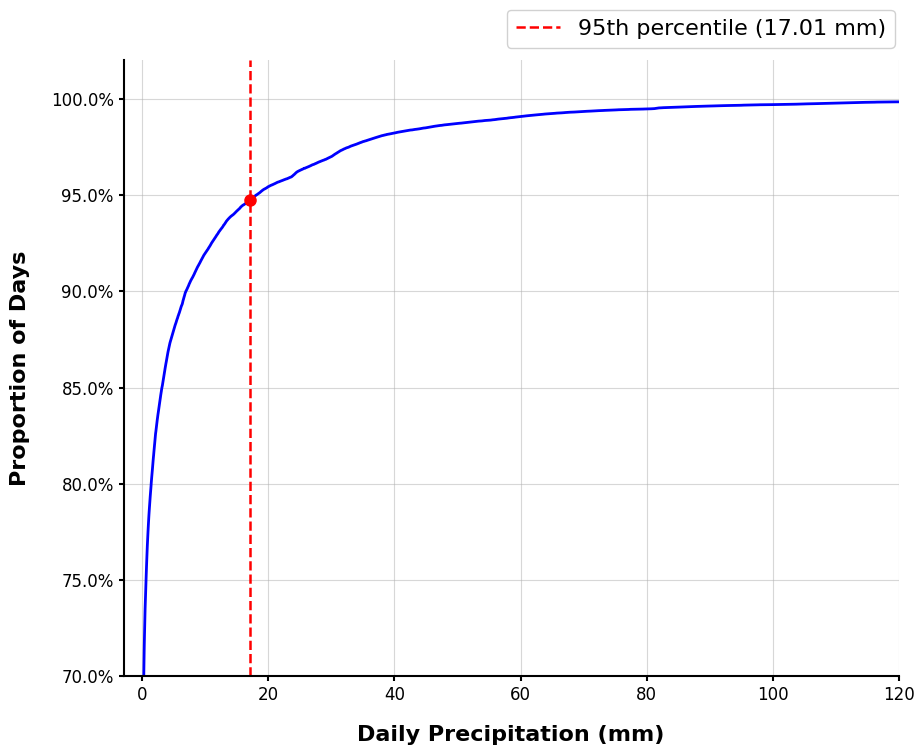

In [22]:
plot_precip_cdf(
    daily_precip_214_eas,
    precip_col='Precip',
    xlim=(-3, 120),
    ylim=(0.7,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Daily Precipitation (mm)',
    ylabel='Proportion of Days',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 17.01, 'color':'red', 'linestyle':'--', 'label':'95th percentile (17.01 mm)'},
        # {'x': 53.59, 'color':'blue', 'linestyle':':', 'label':'99th percentile - daily (53.59 mm)'}
    ], 
    legend_size=16,
    legend_loc='upper left', 
    legend_bbox=(0.48, 1.10), 
    marker_points=[17.01],  
    marker_colors=['red'],
    marker_style='o',
    marker_size=8,
    save_path=PLOTS_DIR / 'supplementary/daily_precip.png'
)

### Daily Stats 

In [23]:
num_days_95 = daily_precip_214_eas[daily_precip_214_eas['Precip'] >= precip_thresh_dict['95']]
# print(f"Total number of days is {len(daily_precip_214_eas):,.0f}\n")
# print(f"Number of days with daily precip >= 95th percentile is {len(num_days_95):,.0f}")

In [24]:
percent_precip_days_95 = len(num_days_95)*100/len(daily_precip_214_eas)
# percent_precip_days_95

## Lightning CDF 

### Daily 

In [25]:
lightning_214_eas_df = hourly_weather.copy().drop(columns = ['Temp', 'Precip', 'Wind Gusts (m/s)'])
daily_lightning_214_eas = lightning_214_eas_df.groupby(['ea_code9ch', 'Date'])['Lightning Events'].sum().reset_index()

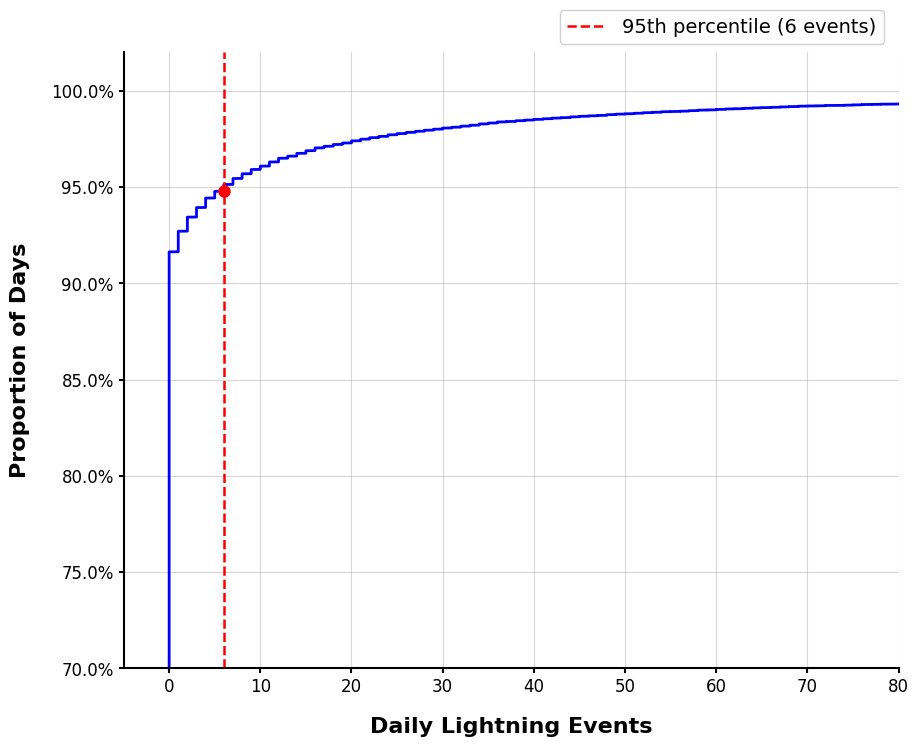

In [26]:
plot_precip_cdf(
    daily_lightning_214_eas,
    precip_col='Lightning Events',
    xlim=(-5, 80),
    ylim=(0.7,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Daily Lightning Events',
    ylabel='Proportion of Days',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 6, 'color':'red', 'linestyle':'--', 'label':'95th percentile (6 events)'},
    ], 
    legend_size=14,
    legend_loc='upper left', 
    legend_bbox=(0.55, 1.085), 
    marker_points=[6, 52],  
    marker_colors=['red'],
    marker_style='o',
    marker_size=8,
    save_path=PLOTS_DIR / 'supplementary/daily_lightning.png'
)

### Daily Stats 

In [27]:
num_days_lightning_95 = daily_lightning_214_eas[daily_lightning_214_eas['Lightning Events'] >= lightning_thresh_dict['95']]

# print(f"Total number of days is {len(daily_lightning_214_eas):,.0f}\n")
# print(f"Number of days with daily lightning >= 95th percentile is {len(num_days_lightning_95):,.0f}")

In [28]:
percent_lightning_days_95 = len(num_days_lightning_95)*100/len(daily_lightning_214_eas)
# percent_lightning_days_95

## Hourly Temp 

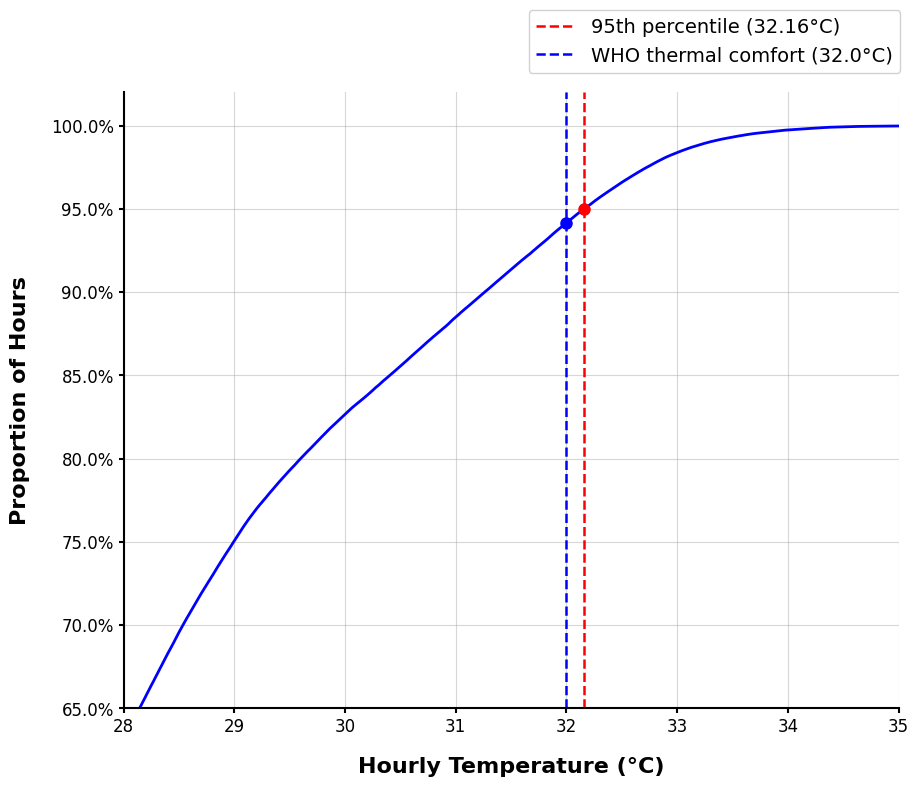

In [29]:
plot_precip_cdf(
    hourly_weather,
    precip_col='Temp',
    xlim=(28, 35),
    ylim=(0.65,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Hourly Temperature (°C)',
    ylabel='Proportion of Hours',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 32.16, 'color':'r', 'linestyle':'--', 'label':'95th percentile (32.16°C)'},
        {'x': 32.0, 'color':'blue', 'linestyle':'--', 'label':'WHO thermal comfort (32.0°C)'}, 
    ], 
    legend_size=14,
    legend_loc='upper left', 
    legend_bbox=(0.51, 1.15), 
    marker_points=[32.16, 32],  
    marker_colors=['r', 'blue'],
    marker_style='o',
    marker_size=8,
    save_path=PLOTS_DIR / 'supplementary/hourly_temp.png'
)

## Daily Temp 

In [30]:
temp_214_eas_df = hourly_weather.copy().drop(columns = ['Lightning Events', 'Precip', 'Wind Gusts (m/s)'])

temp_214_eas_df['Date'] = temp_214_eas_df['time'].dt.floor('D')

# Hot hour flag
temp_214_eas_df['Hot_Hour'] = temp_214_eas_df['Temp'] > hourly_weather['Temp'].quantile(0.95)

# Group by EA and Date, and count Hot_Hour sum
daily_hot_hours_214_eas = (
    temp_214_eas_df.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Hot_Hour': 'sum'})
)

daily_hot_hours_214_eas = daily_hot_hours_214_eas.rename(columns={'Hot_Hour': 'Num_Hot_Hours'})

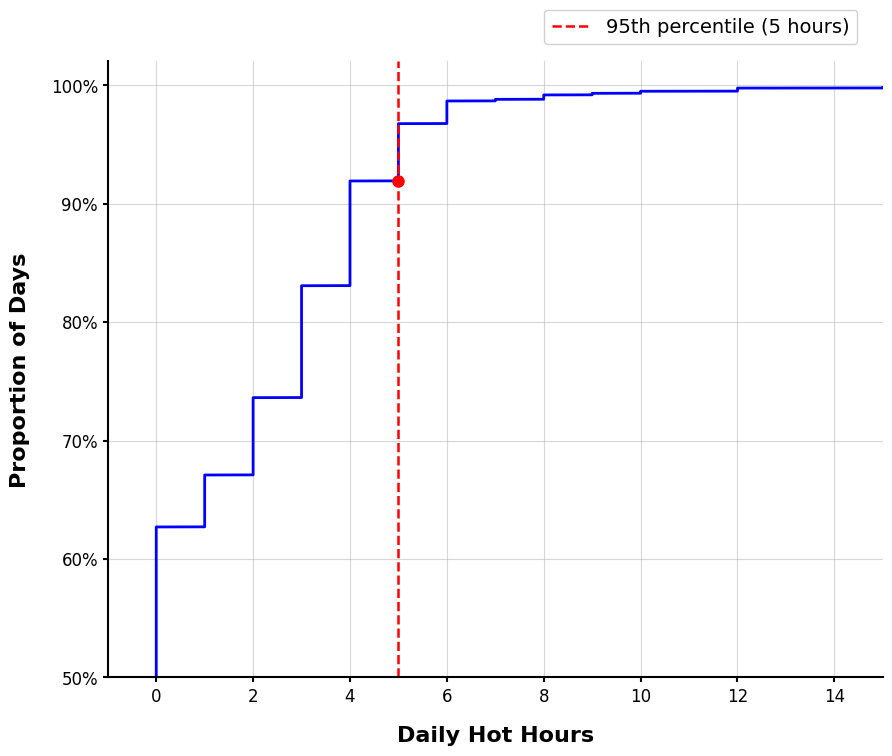

In [31]:
plot_precip_cdf(
    daily_hot_hours_214_eas,
    precip_col='Num_Hot_Hours',
    xlim=(-1, 15),
    ylim=(0.5,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Daily Hot Hours',
    ylabel='Proportion of Days',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 5, 'color':'r', 'linestyle':'--', 'label':'95th percentile (5 hours)'},
    ], 
    legend_size=14,
    legend_loc='upper left', 
    legend_bbox=(0.55, 1.10), 
    marker_points=[5],  
    marker_colors=['r'],
    marker_style='o',
    marker_size=8,
    save_path=PLOTS_DIR / 'supplementary/daily_temp.png'
)

### Daily Stats 

In [32]:
num_days_temp_95 = daily_hot_hours_214_eas[daily_hot_hours_214_eas['Num_Hot_Hours'] >= hot_hrs_thresh_dict['95']]

print(f"Total number of days is {len(daily_hot_hours_214_eas):,.0f}\n")
print(f"Number of days with temp >= 95th percentile is {len(num_days_temp_95):,.0f}")

Total number of days is 155,254

Number of days with temp >= 95th percentile is 12,561


In [33]:
percent_temp_days_95 = len(num_days_temp_95)*100/len(daily_hot_hours_214_eas)
percent_temp_days_95

8.09061280224664

## Wind CDF 

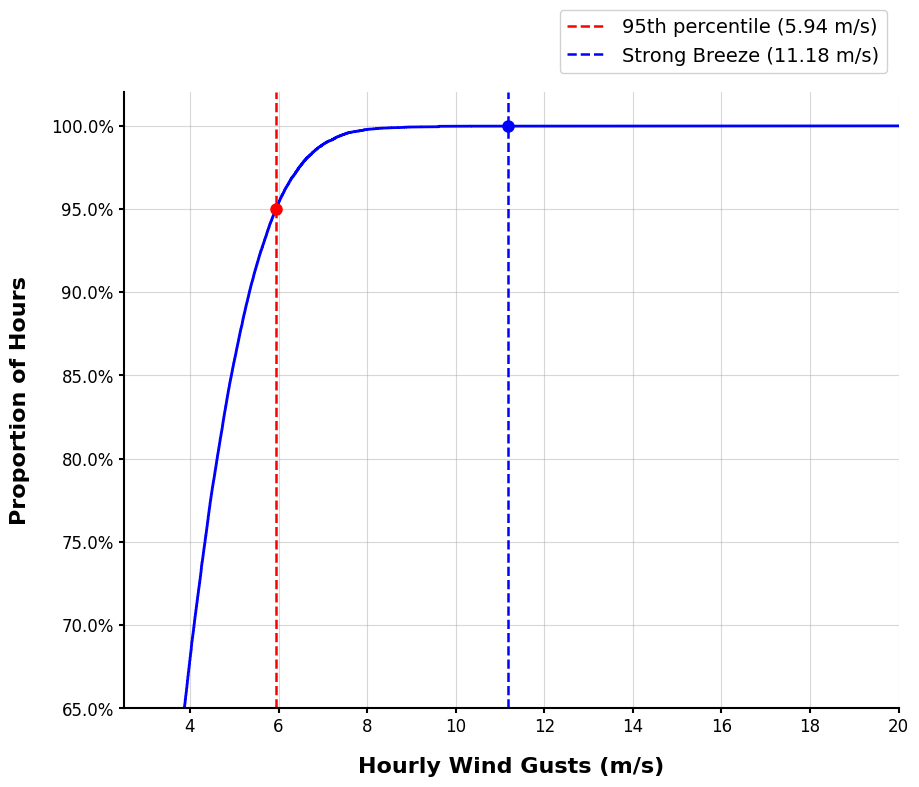

In [34]:
plot_precip_cdf(
    hourly_weather,
    precip_col='Wind Gusts (m/s)',
    xlim=(2.5, 20),
    ylim=(0.65,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Hourly Wind Gusts (m/s)',
    ylabel='Proportion of Hours',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 5.94, 'color':'red', 'linestyle':'--', 'label':'95th percentile (5.94 m/s)'},
        {'x': 11.18, 'color':'blue', 'linestyle':'--', 'label':'Strong Breeze (11.18 m/s)'},
    ], 
    legend_size=14,
    legend_loc='upper left', 
    legend_bbox=(0.55, 1.15), 
    marker_points=[5.94, 11.18],  
    marker_colors=['red', 'blue'],
    marker_style='o',
    marker_size=8,
    save_path=PLOTS_DIR / 'supplementary/hourly_wind.png'
)

### Daily 

In [35]:
wind_214_eas_df = hourly_weather.copy().drop(columns = ['Lightning Events', 'Precip', 'Temp'])

In [36]:
# Windy hour flag
wind_214_eas_df['Windy_Hour'] = wind_214_eas_df['Wind Gusts (m/s)'] > wind_thresh_dict['95']

# Group by EA and Date, and count Windy_Hour sum
daily_windy_hours_214_eas = (
    wind_214_eas_df.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Windy_Hour': 'sum'})
)

daily_windy_hours_214_eas = daily_windy_hours_214_eas.rename(columns={'Windy_Hour': 'Num_Windy_Hours'})

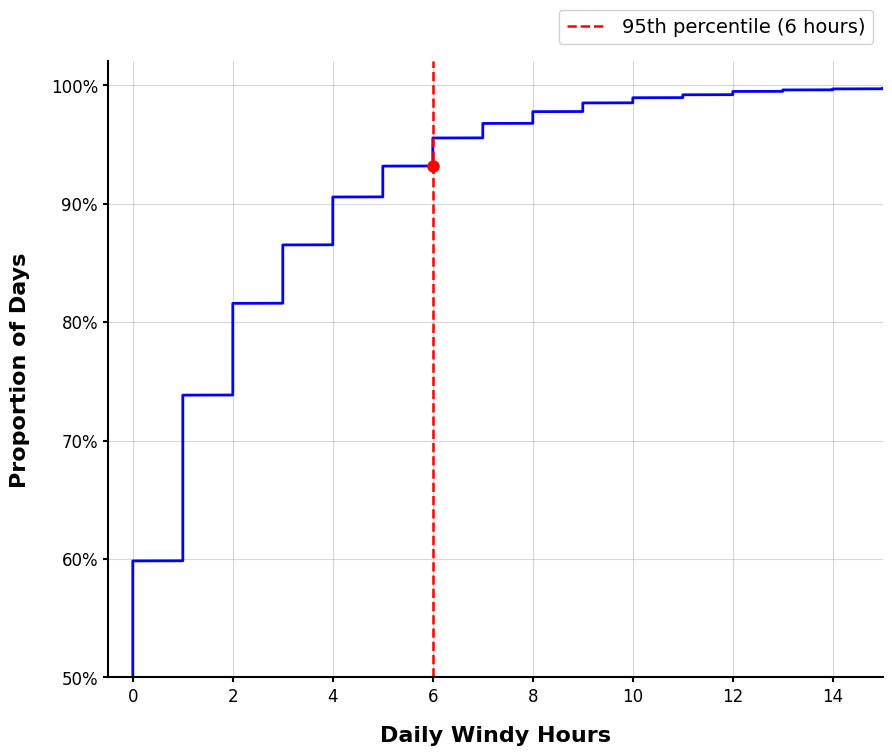

In [37]:
plot_precip_cdf(
    daily_windy_hours_214_eas,
    precip_col='Num_Windy_Hours',
    xlim=(-0.5, 15),
    ylim=(0.5,1.02),
    figsize=(10,8),
    linewidth=2,
    grid_alpha=0.5,
    xlabel='Daily Windy Hours',
    ylabel='Proportion of Days',
    x_ticks_size=12,
    y_ticks_size=12,
    x_label_weight='bold',
    y_label_weight='bold', 
    vlines=[
        {'x': 6, 'color':'red', 'linestyle':'--', 'label':'95th percentile (6 hours)'},
    ], 
    legend_size=14,
    legend_loc='upper left', 
    legend_bbox=(0.57, 1.10), 
    marker_points=[6],  
    marker_colors=['red'],
    marker_style='o',
    marker_size=8,
    save_path=PLOTS_DIR / 'supplementary/daily_wind.png'
)

### Daily Stats 

In [38]:
num_days_wind_95 = daily_windy_hours_214_eas[daily_windy_hours_214_eas['Num_Windy_Hours'] >= windy_hrs_thresh_dict['95']]

# print(f"Total number of days is {len(daily_windy_hours_214_eas):,.0f}\n")
# print(f"Number of days with wind >= 95th percentile is {len(num_days_wind_95):,.0f}")

In [39]:
percent_wind_days_95 = len(num_days_wind_95)*100/len(daily_windy_hours_214_eas)
# percent_wind_days_95